In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import StratifiedShuffleSplit
data = pd.read_csv(r"C:\Users\USER\Documents\ml\datasets\housing\housing.csv")
data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

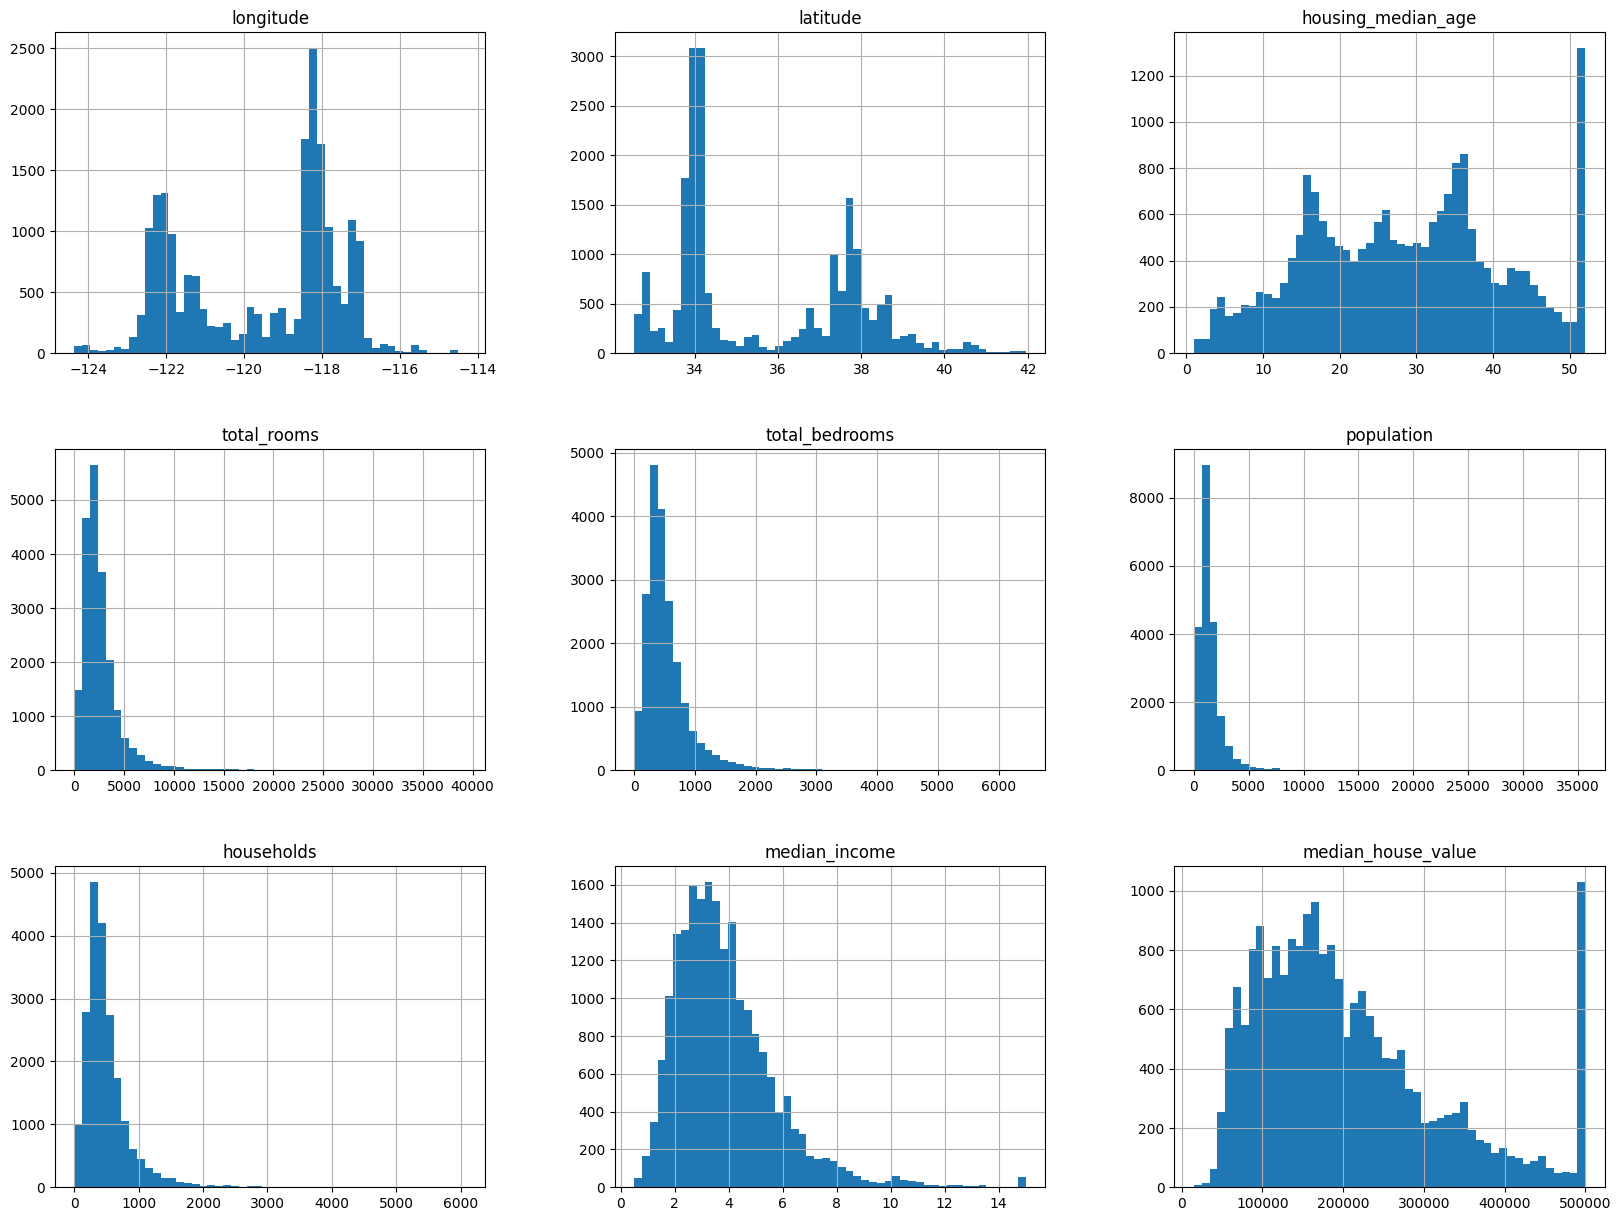

In [3]:
data.hist(bins=50, figsize=(20, 15))

<Axes: xlabel='longitude', ylabel='latitude'>

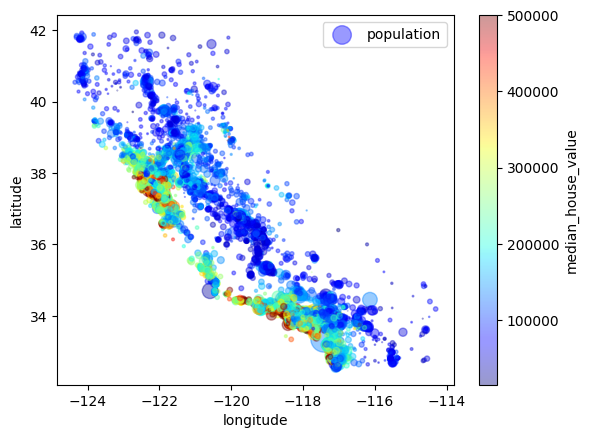

In [9]:
data['income_cat'] = pd.cut(data['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., float('inf')], labels=[1, 2, 3, 4, 5])
data['income_cat'].head()

for train_index, test_index in StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(data, data['income_cat']):
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

for set in (strat_train_set, strat_test_set):
    set.drop('income_cat', axis=1, inplace=True)

housing = strat_train_set.copy()

housing.plot(
    kind='scatter',
    x='longitude',
    y='latitude',
    s=housing['population'] / 100,
    label='population',
    alpha=0.4,
    c='median_house_value',
    cmap=plt.get_cmap('jet'),
    colorbar=True,
)

